In [1]:
from astropy.table import Table
import numpy as np
import arya
import matplotlib.pyplot as plt

In [4]:
dwarf_cat = Table.read("stellar_mass_emline_dwarfs.fits").to_pandas()

In [34]:
emline_cols = [
    'mgii2796',
    'mgii2803',
    'nev3346', 
    'nev3426',
    'oii3726',
    'oii3729',
    'neiii3869',
    'neiii3967',
    'hepsilon',
    'hei4026', 
    'hdelta',
    'hgamma', 
    'oiii4363',
    'hei4471', 
    'heii4686', 
    'hbeta',
    'oiii4959',
    'oiii5007',
    'nii5755',
    'hei5876', 
    'oi6300', 
    'siii6312',
    'nii6548',
    'halpha',  
    'nii6583',
    'sii6716', 
    'sii6731',  
    'hei7065',
    'ariii7136',
    'hei7281',
    'oii7320', 
    'oii7331',
    'ariii7751',
    'siii9071', 
    'siii9533',
]

In [141]:

print(f"{'line':16}{'# 3σ/10^3':8}")
print("-"*25)

filt_all = np.full(len(dwarf_cat), False)

for col in emline_cols:
    flux = dwarf_cat[col + "_flux"]
    fluxerr = dwarf_cat[col + "_fluxerr"]
    snr = flux / fluxerr

    filt_all |= snr > 3
    num_resolved = np.sum(snr > 3) / 1e3
    
    print(f"{col:16}{num_resolved:8.3f}")



print("-"*25)
print(f"{'any line':16}{sum(filt_all)/1e3:8}")

print(f"{'total':16}{len(dwarf_cat['targetid'])/1e3:8.3f}")

print()


line            # 3σ/10^3
-------------------------
mgii2796           0.010
mgii2803           0.004
nev3346            0.085
nev3426            0.161
oii3726          285.271
oii3729          348.155
neiii3869         35.900
neiii3967          4.588
hepsilon           8.543
hei4026            0.318
hdelta            63.263
hgamma           187.812
oiii4363           2.972
hei4471            2.872
heii4686           0.337
hbeta            450.734
oiii4959         274.360
oiii5007         502.420
nii5755            0.230
hei5876           71.843
oi6300            25.514
siii6312           1.329
nii6548           84.467
halpha           338.992
nii6583          259.857
sii6716          441.095
sii6731          355.857
hei7065            7.325
ariii7136         55.932
hei7281            0.498
oii7320            6.944
oii7331            4.737
ariii7751          6.894
siii9071          88.965
siii9533          15.991
-------------------------
any line         593.902
total            665.5

In [143]:
?dwarf_cat.drop_duplicates

Signature:
dwarf_cat.drop_duplicates(
    subset: 'Hashable | Sequence[Hashable] | None' = None,
    *,
    keep: 'DropKeep' = 'first',
    inplace: 'bool' = False,
    ignore_index: 'bool' = False,
) -> 'DataFrame | None'
Docstring:
Return DataFrame with duplicate rows removed.

Considering certain columns is optional. Indexes, including time indexes
are ignored.

Parameters
----------
subset : column label or sequence of labels, optional
    Only consider certain columns for identifying duplicates, by
    default use all of the columns.
keep : {'first', 'last', ``False``}, default 'first'
    Determines which duplicates (if any) to keep.

    - 'first' : Drop duplicates except for the first occurrence.
    - 'last' : Drop duplicates except for the last occurrence.
    - ``False`` : Drop all duplicates.

inplace : bool, default ``False``
    Whether to modify the DataFrame rather than creating a new one.
ignore_index : bool, default ``False``
    If ``True``, the resulting axis will b

In [144]:
len(np.unique(dwarf_cat["targetid"])), 647241

(645790, 647241)

In [145]:
645790/ 647241

0.9977581766297252

In [148]:
dwarf_cat_noduplicate = dwarf_cat.drop_duplicates("targetid")

In [ ]:
np.isdu

In [62]:
dwarf_cat

,xj_sl,target_ra,target_dec,z,zerr,plate_ra,plate_dec,mgii2796_center,mgii2796_centererr,mgii2796_flux,...,sga_norm_d26_dist,aperture_photometry_done,logm_saga_aper,mag_g_aper,mag_r_aper,mag_z_aper,nearest_star_dist,mag_g_updated,mag_r_updated,mag_z_updated
0,"b'{0,0,0,17.17499923706055,21.06040000915527,2...",324.736979,10.459539,0.079849,0.000003,324.736979,10.459539,0.0,0.0,0.0,...,17.116223,0,-99.0,-99.0,-99.0,-99.0,-99.0,19.550291,19.255657,19.043425
1,"b'{0,0,0,2.477400064468384,13.75020027160645,3...",324.746830,10.619419,0.109709,0.000005,324.746830,10.619419,0.0,0.0,0.0,...,211.885810,0,-99.0,-99.0,-99.0,-99.0,-99.0,19.102028,18.810100,18.569807
2,"b'{1.819900035858154,0,0.01789999939501286,0,0...",324.784075,10.539388,0.047602,0.000016,324.784075,10.539388,0.0,0.0,0.0,...,82.015199,0,-99.0,-99.0,-99.0,-99.0,-99.0,19.327467,18.934704,18.677322
3,"b'{0,0,0,0,0.8371999859809875,0,0,0,3.34929990...",324.941568,10.395146,0.077483,0.000060,324.941568,10.395146,0.0,0.0,0.0,...,10.476070,0,-99.0,-99.0,-99.0,-99.0,-99.0,19.882517,19.221685,18.784573
4,"b'{6.836800098419189,0,0,0,0,0,0,0,0,0,0,30.74...",324.959964,10.468438,0.045101,0.000010,324.959964,10.468438,0.0,0.0,0.0,...,18.717081,0,-99.0,-99.0,-99.0,-99.0,-99.0,18.228388,17.759611,17.485638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665499,"b'{0,1.15939998626709,0,19.95730018615723,0,0....",324.470522,10.565312,0.188464,0.000011,324.470522,10.565312,0.0,0.0,0.0,...,1342.156553,0,-99.0,-99.0,-99.0,-99.0,-99.0,19.823038,19.349976,19.081394
665500,"b'{0,0,0,0.0118000004440546,0.7070000171661377...",324.606985,10.384207,0.078214,0.000002,324.606985,10.384207,0.0,0.0,0.0,...,42.045206,0,-99.0,-99.0,-99.0,-99.0,-99.0,18.231583,17.903395,17.669025
665501,"b'{0,0,0,27.49650001525879,0,13.95829963684082...",324.616987,10.435424,0.035153,0.000004,324.616987,10.435424,0.0,0.0,0.0,...,22.453264,0,-99.0,-99.0,-99.0,-99.0,-99.0,19.402052,18.957968,18.708332
665502,"b'{0,17.75679969787598,8.399999618530273,13.33...",324.621041,10.436939,0.194792,0.000005,324.621041,10.436939,0.0,0.0,0.0,...,29.102430,0,-99.0,-99.0,-99.0,-99.0,-99.0,19.827640,19.285670,18.900959


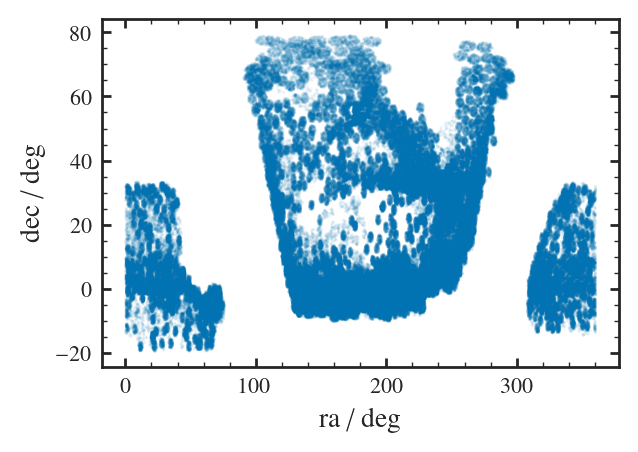

In [10]:
fig, ax = plt.subplots()

ax.set(
    xlabel = "ra / deg",
    ylabel = "dec / deg"
)

ax.scatter(dwarf_cat.ra, dwarf_cat.dec, s=1, lw=0, alpha=0.05)




## Duplicated rows

In [162]:
duplicated_ids = dwarf_cat.targetid[np.where(dwarf_cat.targetid.duplicated())[0]].to_numpy()

In [163]:
duplicated_ids

array([39628451354774374, 39628451358969650, 39628451363160878, ...,
       39633427380569475, 39633427380570088, 39633427380571251],
      shape=(19714,))

In [196]:
dwarf_cat[dwarf_cat.targetid == duplicated_ids[19]][["z", "zerr", "oiii5007_flux", "oiii5007_fluxerr"]]

,z,zerr,oiii5007_flux,oiii5007_fluxerr
6864,0.065851,1.325037e-06,271.180586,14.943818
6865,0.065856,6.315288e-07,300.161204,13.577590


In [198]:
df1 = dwarf_cat.sort_values("zerr")

In [217]:
dwarf_cat_nodup = df1.drop_duplicates("targetid")
dwarf_cat_nodup.sort_values("targetid", inplace=True)

/var/folders/zf/h7t3p5rj5cv9858z697g6fq40000gn/T/ipykernel_47802/3195094903.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dwarf_cat_nodup.sort_values("targetid", inplace=True)


In [218]:
1 - len(dwarf_cat_nodup) / len(dwarf_cat)

0.0296226619223926

about 3 percent of the rows in the final catalogue are duplicated. Why this is the case is not clear to me.

## Dwarf galaxy selection

In [221]:
required_lines = ["nii6583", "halpha", "oiii5007", "hbeta"]#, "oii3726", "oii3729", "oiii4959"]

filt = np.full(len(dwarf_cat_nodup), True)


for line in required_lines:
    filt &= dwarf_cat_nodup[f"{line}_flux"] / dwarf_cat_nodup[f"{line}_fluxerr"] > 3

print(sum(filt))

210768


In [222]:
good_dwarfs = dwarf_cat_nodup[filt]

In [223]:
good_dwarfs

,xj_sl,target_ra,target_dec,z,zerr,plate_ra,plate_dec,mgii2796_center,mgii2796_centererr,mgii2796_flux,...,sga_norm_d26_dist,aperture_photometry_done,logm_saga_aper,mag_g_aper,mag_r_aper,mag_z_aper,nearest_star_dist,mag_g_updated,mag_r_updated,mag_z_updated
432711,"b'{17.13769912719727,0,3.030600070953369,2.729...",26.297520,-17.496308,0.041686,1.707759e-06,26.297520,-17.496308,0.0,0.0,0.0,...,15.393006,0,-99.0,-99.0,-99.0,-99.0,-99.0,19.669138,19.330265,19.189054
432789,"b'{0,0,0,0,0.01169999968260527,45.597198486328...",41.810427,-11.568151,0.068940,1.219826e-06,41.810427,-11.568151,0.0,0.0,0.0,...,131.809807,0,-99.0,-99.0,-99.0,-99.0,-99.0,20.056180,19.806477,19.701965
392789,"b'{0.9003999829292297,0,0,64.69439697265625,0,...",32.033669,-11.051509,0.040596,7.798278e-07,32.033669,-11.051509,0.0,0.0,0.0,...,122.126779,0,-99.0,-99.0,-99.0,-99.0,-99.0,19.651500,19.621952,19.744190
401956,"b'{11.11489963531494,7.691299915313721,0,0,0,1...",60.835849,-9.054503,0.036918,3.604419e-06,60.835849,-9.054503,0.0,0.0,0.0,...,11.177884,0,-99.0,-99.0,-99.0,-99.0,-99.0,20.585255,20.185040,19.982725
433349,"b'{0,0,1.526800036430359,0,0,0,0,0,0,36.093601...",132.972160,-8.343442,0.024952,2.886412e-06,132.972160,-8.343442,0.0,0.0,0.0,...,343.545919,0,-99.0,-99.0,-99.0,-99.0,-99.0,19.944534,19.674140,19.535202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619262,"b'{0,0,0,0,0,0,25.82200050354004,0,0,0,31.7775...",256.460376,32.272001,0.183186,4.175235e-06,256.460376,32.272001,0.0,0.0,0.0,...,584.692504,0,-99.0,-99.0,-99.0,-99.0,-99.0,19.727026,19.292600,19.049469
619263,"b'{0,7.159200191497803,0,8.270299911499023,0,8...",256.510273,32.240679,0.084947,4.157251e-06,256.510273,32.240679,0.0,0.0,0.0,...,133.016688,0,-99.0,-99.0,-99.0,-99.0,-99.0,18.566483,18.276308,17.964474
268167,"b'{3.379400014877319,0,0.09719999879598618,18....",256.579098,32.283478,0.062667,1.570315e-06,256.579098,32.283478,0.0,0.0,0.0,...,42.083844,0,-99.0,-99.0,-99.0,-99.0,-99.0,20.038748,19.674522,19.489805
268168,"b'{0,0.02779999934136868,0,0,0.010900000110268...",256.597475,32.188241,0.085196,3.244298e-06,256.597475,32.188241,0.0,0.0,0.0,...,101.343239,0,-99.0,-99.0,-99.0,-99.0,-99.0,19.809944,19.521446,19.305878


## BPT screening diagram

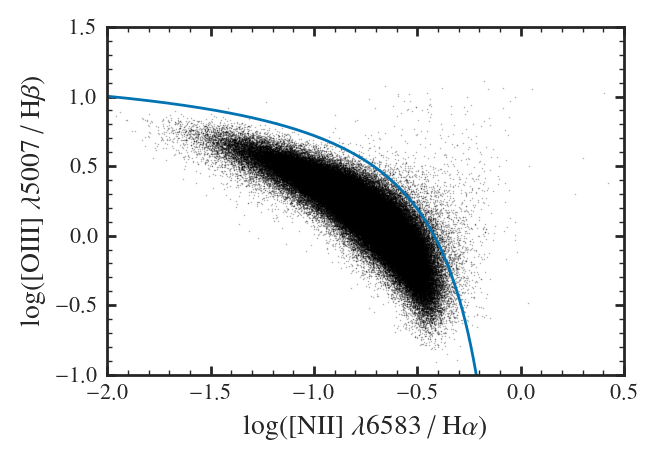

In [224]:
fig, ax = plt.subplots()
ax.set(
    xlabel = r"log([NII] $\lambda$6583 / H$\alpha$)",
    ylabel = r"log([OIII] $\lambda$5007 / H$\beta$)",
    xlim = (-2, 0.5),
    ylim = (-1, 1.5),
)


x = np.log10(good_dwarfs["nii6583_flux"] / good_dwarfs["halpha_flux"])
y = np.log10(good_dwarfs["oiii5007_flux"] / good_dwarfs["hbeta_flux"])

plt.scatter(x, y, s=0.3, alpha=0.3, color="k", lw=0)


# x_model = np.linspace(-2, 0.15, 1000)
# y_model = 0.61 / (x_model - 0.15) + 1.4 # Eq. 1 from Zou+2024, +0.1 dex modelling uncertainty shift in both directions
# plt.plot(x_model, y_model)

x_model = np.linspace(-2, -0.05, 1000)
y_model = 0.61 / (x_model - 0.15 + 0.1) + 1.3 # the original Kauffmann+2003 separation
plt.plot(x_model, y_model)

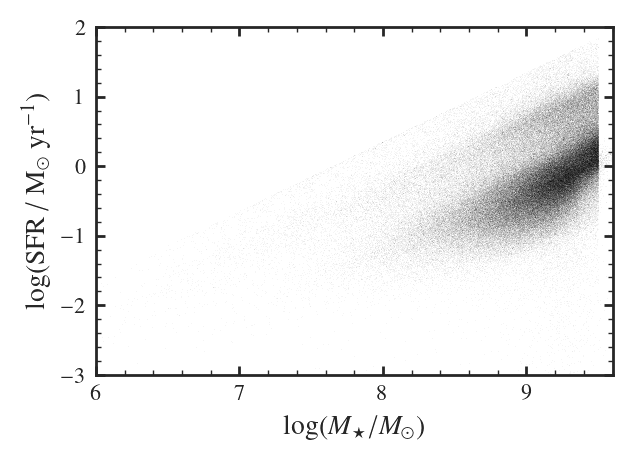

In [225]:
fig, ax = plt.subplots()
ax.set(
    xlabel = r"log($M_\star / M_\odot$)",
    ylabel = r"log(SFR / M$_\odot$ yr$^{-1}$)",
    xlim = (6, 9.6),
    ylim = (-3, 2),
)

x = good_dwarfs["logm_cigale"]
y = good_dwarfs["logsfr_cigale"] 

plt.scatter(x, y, s=0.1, color="black", alpha=0.03, lw=0)

In [226]:
eps_o_sun = 8.7

In [227]:
Z_SUN = 0.014

In [228]:
np.random.choice(good_dwarfs["targetid"])

np.int64(39633034340732016)

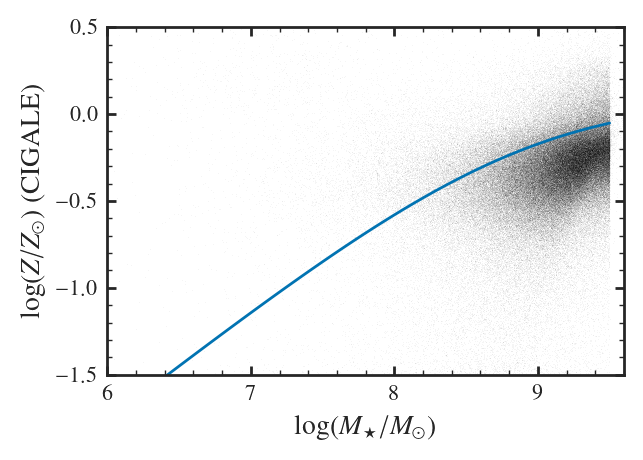

In [229]:
fig, ax = plt.subplots()
ax.set(
    xlabel = r"log($M_\star / M_\odot$)",
    ylabel = r"$\log(Z/Z_\odot)$ (CIGALE)",
    xlim = (6, 9.6),
    ylim = (-1.5, 0.5),
)

x = good_dwarfs["logm_cigale"]
y = np.log10(good_dwarfs["z_cg"] / Z_SUN)

plt.scatter(x, y, s=0.1, color="black", alpha=0.03, lw=0)

x_model = np.linspace(6, 9.5)
y_model = andrews_martini_mzr(10**x_model) - eps_o_sun


plt.plot(x_model, y_model)

In [230]:
def andrews_martini_mzr(m_star):
    eps_o_asm = 8.798
    gamma = 0.640
    log_m_to = 8.90

    eps_o = eps_o_asm - np.log10(1 + (10**log_m_to / m_star)**gamma)
    return eps_o
    